## Camshift

This algorithm has been developed by opencv and its an improvement of meanshift in static rectangle size

**Libraries**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Capturing Video and calculating histogram for first gram**

In [2]:
cap = cv2.VideoCapture('videos/slow_traffic_small.mp4')
# Take first frame of the video. we will set our kernel and window over this frame and will pass it to meanshift
ret,frame = cap.read()
# Setup initial location of window(we can find it with object detectors ...)
x, y, w, h = 300, 200, 100, 50
track_window = (x, y, w, h)
#Set up the region of interest for tracking over the frame
roi = frame[y:y+h, x:x+w]
#Convert it to HSV, why? hue channel can be a competent deligate for histogram and back-project calculation
hsv_roi =  cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
#Set up Limitations over saturation and value channels(we don't need dark pixels)
mask = cv2.inRange(hsv_roi, np.array((0., 60.,32.)), np.array((180.,255.,255.)))
#Calculate histogram with given mask and hsv-roi
roi_hist = cv2.calcHist([hsv_roi],[0],mask,[180],[0,180])
cv2.normalize(roi_hist,roi_hist,0,255,cv2.NORM_MINMAX)

array([[  6.8     ],
       [  0.      ],
       [  0.      ],
       [  3.4     ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [  0. 

In [4]:
# Setup the termination criteria, either 10 iteration or move by at least 1 pt
term_crit = ( cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1 )

**Tracking over video's frames**

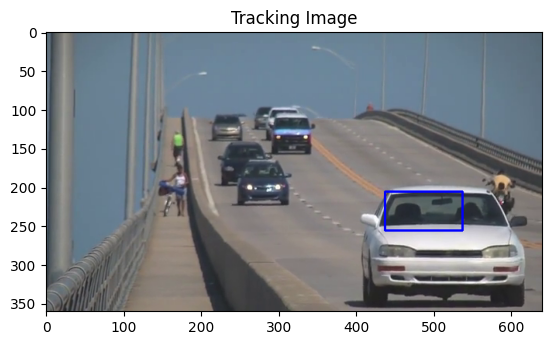

In [5]:
while True:
    ret, frame = cap.read()
    if ret == True:
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        #now we will calculate back project with given roi-histogram and new frame(hsv format)
        dst = cv2.calcBackProject([hsv],[0],roi_hist,[0,180],1)
        # Apply meanshift to get the new location of our object and area
        ret, track_window = cv2.meanShift(dst, track_window, term_crit)
        # Draw it on image
        x,y,w,h = track_window
        tracking_image = cv2.rectangle(frame, (x,y), (x+w,y+h), 255,2)
        cv2.imshow('tracking image',tracking_image)
        k = cv2.waitKey(30) & 0xff
        if k == 27:
            plt.imshow(tracking_image[...,::-1], cmap="gray"); plt.title("Tracking Image")
            break
    else:
        break
        
cv2.destroyAllWindows()